# 05 · Modelado: pronóstico de RÉPLICAS (CRISP-DM — Fase 4b)

> ## ⚠️ Lectura obligatoria
> Este modelo pronostica la **TASA ESPERADA de réplicas por día** tras un gran
> sismo (una estadística de la secuencia), **NO eventos individuales**. No dice
> "habrá una réplica M5 mañana en Muisne"; dice "cabe esperar del orden de N
> réplicas M≥4.5 por día a t días del sismo principal". La ocurrencia concreta
> de cada réplica es estocástica (aprox. Poisson no estacionario).

**Caso de estudio: terremoto de Pedernales**, 16 de abril de 2016, M7.8
(epicentro frente a las costas de Manabí/Esmeraldas, interfaz de subducción).

Modelo: **ley de Omori-Utsu** — r(t) = K / (t + c)^p, donde r(t) es la tasa
diaria de réplicas a t días del sismo principal. Valores típicos de p ≈ 0.8–1.5.

In [1]:
# --- Configuración común ---
import os
import sys
import pathlib

In [2]:
RAIZ = pathlib.Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ))

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = pathlib.Path("reports/figures")

In [5]:
from src.models import tasa_omori, ajustar_omori_mle

In [6]:
# --- Carga del catálogo M≥3 (mejor resolución para secuencias de réplicas) ---
catalogo = pd.read_csv("data/raw/catalogo_sismico_ecuador_M3_1983_2026.csv")
catalogo["fecha_hora"] = pd.to_datetime(catalogo["time"], utc=True)
catalogo = catalogo[catalogo["type"] == "earthquake"]
print(f"Catálogo M≥3: {len(catalogo)} eventos")

Catálogo M≥3: 2792 eventos


In [7]:
# --- Aislamos la secuencia de Pedernales 2016 ---
# Sismo principal: el mayor evento de abril de 2016 en la región
abril2016 = catalogo[(catalogo["fecha_hora"] >= "2016-04-16") &
                     (catalogo["fecha_hora"] <= "2016-04-17")]
principal = abril2016.loc[abril2016["mag"].idxmax()]
print(f"Sismo principal: M{principal['mag']} el {principal['time']} "
      f"en ({principal['latitude']:.3f}, {principal['longitude']:.3f}), "
      f"prof. {principal['depth']:.0f} km")

Sismo principal: M7.8 el 2016-04-16T23:58:36.980Z en (0.382, -79.922), prof. 21 km


In [8]:
# Réplicas: eventos M≥4.5 en un radio de 150 km, en los 120 días siguientes
RADIO_KM = 150.0
DIAS_VENTANA = 120
UMBRAL_MAG = 4.5

In [9]:
dist_grados = np.hypot(catalogo["latitude"] - principal["latitude"],
                       catalogo["longitude"] - principal["longitude"])
# 1 grado ≈ 111 km; suficiente para seleccionar el radio
secuencia = catalogo[(dist_grados * 111 <= RADIO_KM) &
                     (catalogo["fecha_hora"] > principal["fecha_hora"]) &
                     (catalogo["fecha_hora"] <= principal["fecha_hora"] +
                      pd.Timedelta(days=DIAS_VENTANA)) &
                     (catalogo["mag"] >= UMBRAL_MAG)].copy()
secuencia["dias"] = (secuencia["fecha_hora"] - principal["fecha_hora"]).dt.total_seconds() / 86400
print(f"Réplicas M≥{UMBRAL_MAG} en {DIAS_VENTANA} días, radio {RADIO_KM:.0f} km: {len(secuencia)}")

Réplicas M≥4.5 en 120 días, radio 150 km: 51


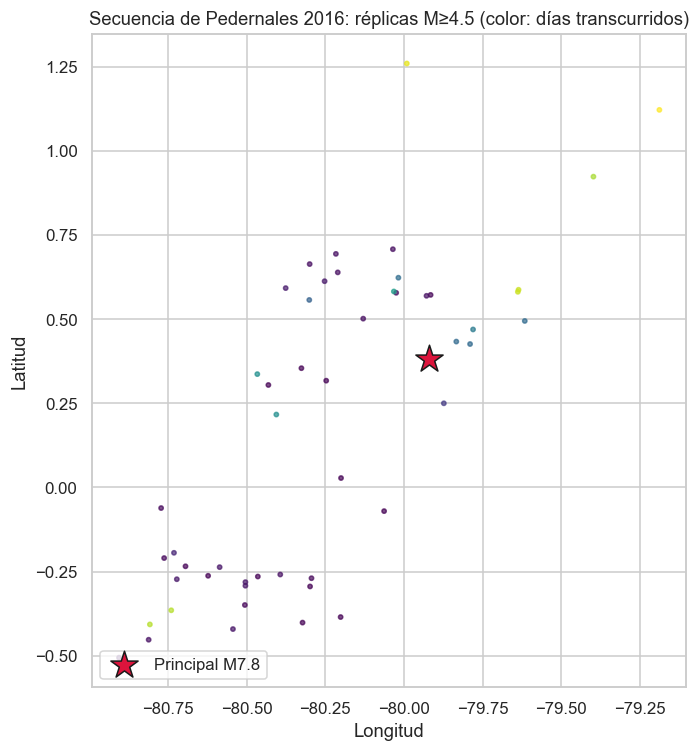

In [10]:
# --- Figura: epicentros del principal y sus réplicas ---
fig, eje = plt.subplots(figsize=(6.5, 7))
eje.scatter(secuencia["longitude"], secuencia["latitude"], s=8, c=secuencia["dias"],
            cmap="viridis", alpha=0.7)
eje.scatter([principal["longitude"]], [principal["latitude"]], marker="*", s=350,
            c="crimson", edgecolor="k", label=f"Principal M{principal['mag']}")
eje.set_title("Secuencia de Pedernales 2016: réplicas M≥4.5 (color: días transcurridos)")
eje.set_xlabel("Longitud"); eje.set_ylabel("Latitud"); eje.legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIG / "05_mapa_secuencia.png", bbox_inches="tight")
plt.show()

In [11]:
# --- Tasas diarias observadas ---
dias = np.arange(1, DIAS_VENTANA + 1)
tasas = np.array([( (secuencia["dias"] >= d - 0.5) & (secuencia["dias"] < d + 0.5) ).sum()
                  for d in dias], dtype=float)
print(f"Total réplicas contadas: {tasas.sum():.0f} | día 1: {tasas[0]:.0f} | día 30: {tasas[29]:.0f}")

Total réplicas contadas: 40 | día 1: 1 | día 30: 0


In [12]:
# --- División entrenamiento / validación ---
# Entrenamos con los primeros 60 días (verosimilitud de un proceso de Poisson
# no estacionario sobre los tiempos de cada réplica) y validamos contra los
# días 61–120 reales: una extrapolación genuina fuera de muestra.
DIAS_ENTRENA = 60
t_entrena = secuencia.loc[secuencia["dias"] <= DIAS_ENTRENA, "dias"].values
params, cov = ajustar_omori_mle(t_entrena, T=DIAS_ENTRENA)
K, c, p = params
errores = 2 * np.sqrt(np.diag(cov))  # aprox. 95% con 2σ
print(f"\nOmori-Utsu (entrenado con días 1–{DIAS_ENTRENA}, n={len(t_entrena)} réplicas):")
print(f"  K = {K:.2f} ± {errores[0]:.2f}")
print(f"  c = {c:.2f} ± {errores[1]:.2f} días")
print(f"  p = {p:.2f} ± {errores[2]:.2f}")
print(f"  Tasa esperada: día 1 ≈ {tasa_omori(1, K, c, p):.1f} réplicas/día; "
      f"día 30 ≈ {tasa_omori(30, K, c, p):.2f}/día")


Omori-Utsu (entrenado con días 1–60, n=44 réplicas):
  K = 5.38 ± 2.95
  c = 0.04 ± 0.11 días
  p = 0.86 ± 0.23
  Tasa esperada: día 1 ≈ 5.2 réplicas/día; día 30 ≈ 0.28/día


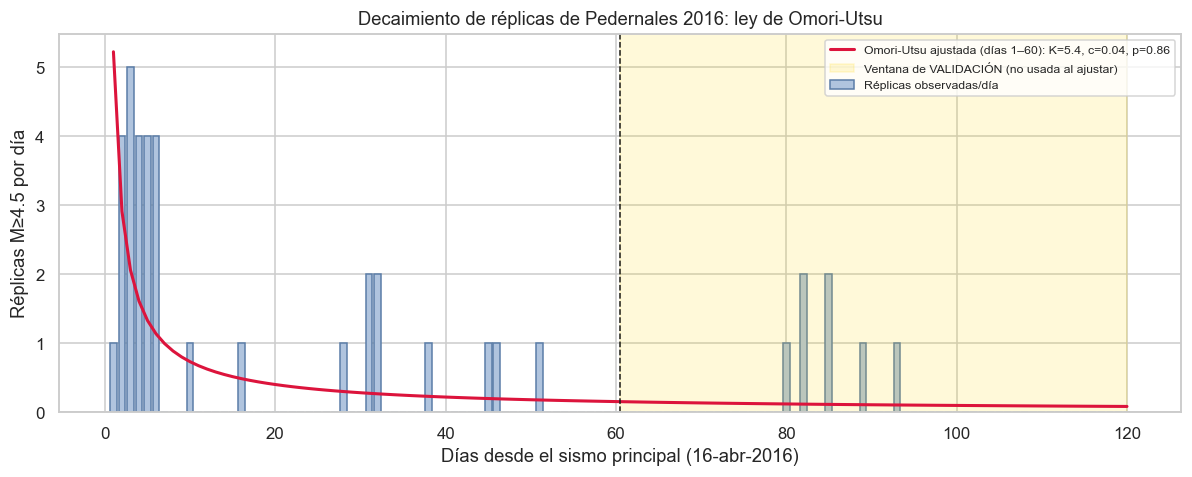

In [13]:
# --- Figura: ajuste y validación fuera de muestra ---
pred = tasa_omori(dias.astype(float), K, c, p)
fig, eje = plt.subplots(figsize=(11, 4.5))
eje.bar(dias, tasas, color="#B0C4DE", edgecolor="#5B7DA8", label="Réplicas observadas/día")
eje.plot(dias, pred, c="crimson", lw=2,
         label=f"Omori-Utsu ajustada (días 1–{DIAS_ENTRENA}): K={K:.1f}, c={c:.2f}, p={p:.2f}")
eje.axvspan(DIAS_ENTRENA + 0.5, DIAS_VENTANA, color="gold", alpha=0.15,
            label="Ventana de VALIDACIÓN (no usada al ajustar)")
eje.axvline(DIAS_ENTRENA + 0.5, ls="--", c="k", lw=1)
eje.set_xlabel("Días desde el sismo principal (16-abr-2016)")
eje.set_ylabel("Réplicas M≥4.5 por día")
eje.set_title("Decaimiento de réplicas de Pedernales 2016: ley de Omori-Utsu")
eje.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "05_omori_ajuste_validacion.png", bbox_inches="tight")
plt.show()

In [14]:
# --- Métricas dentro y fuera de muestra ---
def metricas(y_real, y_pred):
    rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))
    mae = np.mean(np.abs(y_real - y_pred))
    # devianza Poisson (verosimilitud de proceso de conteo)
    con = y_real > 0
    dev = 2 * np.sum(y_real[con] * np.log(y_real[con] / np.maximum(y_pred[con], 1e-9))
                     - (y_real[con] - y_pred[con]))
    return {"RMSE": rmse, "MAE": mae, "Devianza_Poisson": dev}

In [15]:
entrena_m = metricas(tasas[:DIAS_ENTRENA], pred[:DIAS_ENTRENA])
valida_m = metricas(tasas[DIAS_ENTRENA:], pred[DIAS_ENTRENA:])
tabla = pd.DataFrame({"Entrenamiento (d 1–60)": entrena_m,
                      "Validación (d 61–120)": valida_m}).round(2)
tabla

,Entrenamiento (d 1–60),Validación (d 61–120)
RMSE,1.04,0.41
MAE,0.66,0.21
Devianza_Poisson,35.71,22.88


**Interpretación:**
- `p` cerca de 1 → decaimiento hiperbólico clásico: la tasa cae ~10× cada cierto
  intervalo; pasadas ~2–3 semanas la secuencia se aproxima al fondo sísmico regional.
- La validación fuera de muestra (días 61–120) muestra el desempeño realista del
  pronóstico de TASA (ver métricas y figura; la sobretasa del 18-may-2016 M6.9
  de la misma secuencia ilustra la naturaleza estocástica y por etapas de las réplicas).

**Nota sobre extensiones:** un modelo ETAS ( Epidemic-Type Aftershock Sequence)
descompone el catálogo en sismos de fondo + réplicas de segundo orden y añade
la productividad en función de magnitud (ley de Bath). Para un caso de uso
operacional real conviene implementarlo completo; aquí Omori-Utsu captura el
patrón de primer orden con total transparencia.

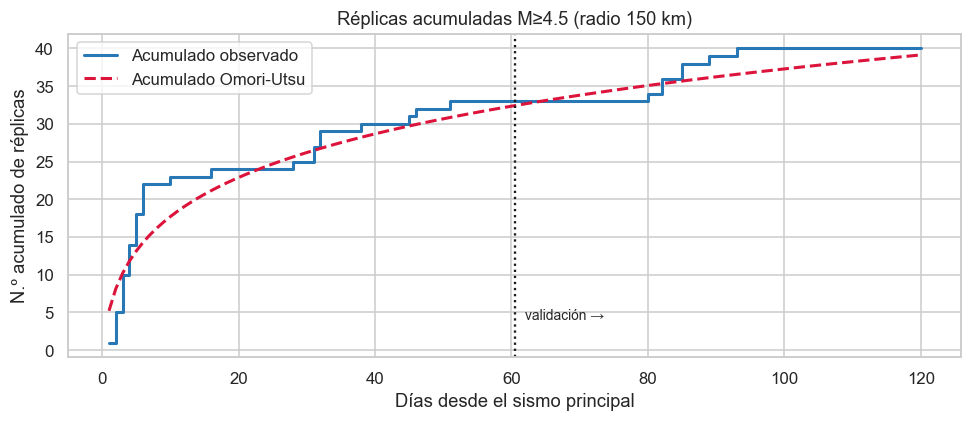

In [16]:
# --- Figura: número acumulado de réplicas (otra vista del ajuste) ---
acum_obs = np.cumsum(tasas)
acum_pred = np.cumsum(pred)
fig, eje = plt.subplots(figsize=(9, 4))
eje.step(dias, acum_obs, where="post", c="#2878B5", lw=2, label="Acumulado observado")
eje.plot(dias, acum_pred, c="crimson", ls="--", lw=2, label="Acumulado Omori-Utsu")
eje.axvline(DIAS_ENTRENA + 0.5, ls=":", c="k")
eje.text(DIAS_ENTRENA + 2, acum_obs.max() * 0.1, "validación →", fontsize=9)
eje.set_xlabel("Días desde el sismo principal"); eje.set_ylabel("N.º acumulado de réplicas")
eje.set_title(f"Réplicas acumuladas M≥{UMBRAL_MAG} (radio {RADIO_KM:.0f} km)")
eje.legend()
plt.tight_layout()
plt.savefig(FIG / "05_omori_acumulado.png", bbox_inches="tight")
plt.show()

## Resumen de la fase 4b

| Elemento | Valor |
|---|---|
| Sismo principal | 16-abr-2016, M7.8 (interfaz de subducción) |
| Réplicas usadas | M≥4.5, radio 150 km, 120 días |
| Modelo | Omori-Utsu r(t)=K/(t+c)^p, MLE de Poisson no estacionario |
| Entrenamiento | días 1–60 · **Validación** días 61–120 |

Recordatorio final: **pronosticamos tasas, no eventos individuales** — y esa es
exactamente la frontera de la ciencia actual (USGS: los sismos no son
predecibles a corto plazo; las réplicas sí siguen leyes estadísticas).